## Lab Assignment


1. Construct an SVM model using the data voice.csv under the following conditions,

a. Split the data using ratios of 70:30 and 80:20 for each model to be developed.

  i. Use a model with a linear kernel.

  ii. Use a model with a polynomial kernel.

  iii. Use a model with an RBF kernel.

b. Tabulate the performance of each split and kernel based on the accuracy metric.

2. Use the data from practical session 5 to develop a daytime and nighttime classification model using an SVM with an RBF kernel employing histogram features. Use an 80:20 ratio. You may experiment with hyperparameter tuning of the RBF kernel. Record the accuracy performance!

**Number 1**

Step 0 - Load and Prepare Dataset

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('voice.csv')

# Display the first few rows
print("First few rows of the dataset:")
display(df.head())

# Check for missing values
print("\nMissing values in the dataset:")
display(df.isnull().sum())

# Separate features and target
X = df.drop('label', axis=1)
y = df['label']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

First few rows of the dataset:


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male



Missing values in the dataset:


,0
meanfreq,0
sd,0
median,0
Q25,0
Q75,0
IQR,0
skew,0
kurt,0
sp.ent,0
sfm,0


Step 1 - Split the Data

In [3]:
from sklearn.model_selection import train_test_split

# Split the data with a 70:30 ratio
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Split the data with an 80:20 ratio
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("Data split into 70:30 ratio:")
print(f"X_train_70 shape: {X_train_70.shape}")
print(f"X_test_70 shape: {X_test_70.shape}")
print(f"y_train_70 shape: {y_train_70.shape}")
print(f"y_test_70 shape: {y_test_70.shape}")

print("\nData split into 80:20 ratio:")
print(f"X_train_80 shape: {X_train_80.shape}")
print(f"X_test_80 shape: {X_test_80.shape}")
print(f"y_train_80 shape: {y_train_80.shape}")
print(f"y_test_80 shape: {y_test_80.shape}")

Data split into 70:30 ratio:
X_train_70 shape: (2217, 20)
X_test_70 shape: (951, 20)
y_train_70 shape: (2217,)
y_test_70 shape: (951,)

Data split into 80:20 ratio:
X_train_80 shape: (2534, 20)
X_test_80 shape: (634, 20)
y_train_80 shape: (2534,)
y_test_80 shape: (634,)


Step 2a - Train and Evaluate SVM Models with Linear Kernel

In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Instantiate and train the first model (70:30 split)
svm_linear_70 = SVC(kernel='linear')
svm_linear_70.fit(X_train_70, y_train_70)

# Make predictions and calculate accuracy for the 70:30 split
y_pred_linear_70 = svm_linear_70.predict(X_test_70)
accuracy_linear_70 = accuracy_score(y_test_70, y_pred_linear_70)

# Instantiate and train the second model (80:20 split)
svm_linear_80 = SVC(kernel='linear')
svm_linear_80.fit(X_train_80, y_train_80)

# Make predictions and calculate accuracy for the 80:20 split
y_pred_linear_80 = svm_linear_80.predict(X_test_80)
accuracy_linear_80 = accuracy_score(y_test_80, y_pred_linear_80)

# Print the accuracy scores
print(f"Accuracy for 70:30 split (Linear Kernel): {accuracy_linear_70}")
print(f"Accuracy for 80:20 split (Linear Kernel): {accuracy_linear_80}")

Accuracy for 70:30 split (Linear Kernel): 0.9263932702418507
Accuracy for 80:20 split (Linear Kernel): 0.9416403785488959


Step 2b - Train and Evaluate SVM Models with Polynomial Kernel

In [5]:
# Instantiate and train the first model (70:30 split) with polynomial kernel
svm_poly_70 = SVC(kernel='poly')
svm_poly_70.fit(X_train_70, y_train_70)

# Make predictions and calculate accuracy for the 70:30 split
y_pred_poly_70 = svm_poly_70.predict(X_test_70)
accuracy_poly_70 = accuracy_score(y_test_70, y_pred_poly_70)

# Instantiate and train the second model (80:20 split) with polynomial kernel
svm_poly_80 = SVC(kernel='poly')
svm_poly_80.fit(X_train_80, y_train_80)

# Make predictions and calculate accuracy for the 80:20 split
y_pred_poly_80 = svm_poly_80.predict(X_test_80)
accuracy_poly_80 = accuracy_score(y_test_80, y_pred_poly_80)

# Print the accuracy scores
print(f"Accuracy for 70:30 split (Polynomial Kernel): {accuracy_poly_70}")
print(f"Accuracy for 80:20 split (Polynomial Kernel): {accuracy_poly_80}")

Accuracy for 70:30 split (Polynomial Kernel): 0.4900105152471083
Accuracy for 80:20 split (Polynomial Kernel): 0.48264984227129337


Step 2c - Train and Evaluate SVM Models with RBF Kernel

In [6]:
# Instantiate and train the first model (70:30 split) with RBF kernel
svm_rbf_70 = SVC(kernel='rbf')
svm_rbf_70.fit(X_train_70, y_train_70)

# Make predictions and calculate accuracy for the 70:30 split
y_pred_rbf_70 = svm_rbf_70.predict(X_test_70)
accuracy_rbf_70 = accuracy_score(y_test_70, y_pred_rbf_70)

# Instantiate and train the second model (80:20 split) with RBF kernel
svm_rbf_80 = SVC(kernel='rbf')
svm_rbf_80.fit(X_train_80, y_train_80)

# Make predictions and calculate accuracy for the 80:20 split
y_pred_rbf_80 = svm_rbf_80.predict(X_test_80)
accuracy_rbf_80 = accuracy_score(y_test_80, y_pred_rbf_80)

# Print the accuracy scores
print(f"Accuracy for 70:30 split (RBF Kernel): {accuracy_rbf_70}")
print(f"Accuracy for 80:20 split (RBF Kernel): {accuracy_rbf_80}")

Accuracy for 70:30 split (RBF Kernel): 0.6624605678233438
Accuracy for 80:20 split (RBF Kernel): 0.6561514195583596


Step 3 - Tabulate Results

In [7]:
import pandas as pd

# Create a DataFrame to store the results
accuracy_table = pd.DataFrame({
    'Split Ratio': ['70:30', '70:30', '70:30', '80:20', '80:20', '80:20'],
    'Kernel': ['Linear', 'Polynomial', 'RBF', 'Linear', 'Polynomial', 'RBF'],
    'Accuracy': [accuracy_linear_70, accuracy_poly_70, accuracy_rbf_70, accuracy_linear_80, accuracy_poly_80, accuracy_rbf_80]
})

# Display the accuracy table
display(accuracy_table)

,Split Ratio,Kernel,Accuracy
0,70:30,Linear,0.926393
1,70:30,Polynomial,0.490011
2,70:30,RBF,0.662461
3,80:20,Linear,0.941640
4,80:20,Polynomial,0.482650
5,80:20,RBF,0.656151


**Number 2**

Day/Night Classification (Histogram + SVM RBF)
Total Training Samples: 240
Total Test Samples: 160
Feature Dimension per Sample: 512 (512 HSV features)
--------------------------------------------------

Example of Training Images Used:


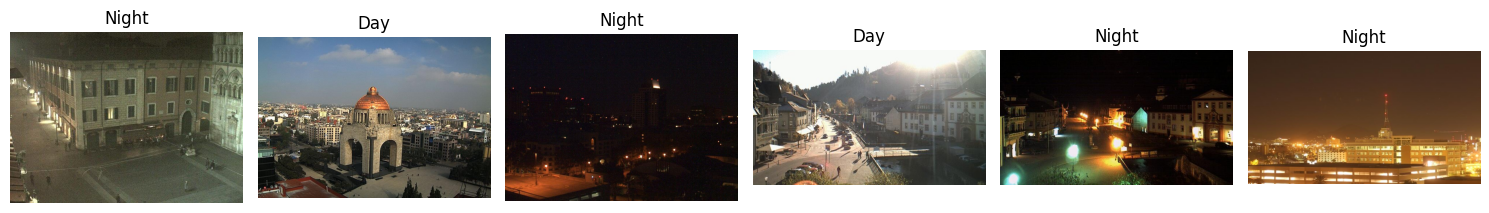


RESULTS OF HYPERPARAMETER TUNING (GRID SEARCH)
Best Parameters: C=1, gamma=scale
Best Cross-Validation Score (Training Set): 0.9875
Accuracy Performance (Test Data): 88.12%


In [11]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# --- I. CONFIGURATION AND DATA PREPARATION ---

# Path to the main image data directory
PATH_IMAGES = '/content/drive/MyDrive/Machine Learning 2025/images'

print("Day/Night Classification (Histogram + SVM RBF)")

# 1. Histogram Feature Extraction Function (Using 3D HSV: 512 Features)
def extract_histogram_features(image_path, bins=(8, 8, 8)):
    """Reads an image, computes a 3D HSV histogram (512 features), and normalizes it."""
    img = cv2.imread(image_path)
    if img is None:
        return None

    try:
        # Convert BGR to HSV. HSV is better for capturing color/brightness differences.
        img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    except cv2.error:
        # If conversion fails (e.g., corrupted file), skip this image
        return None

    # Compute 3D histogram: 8*8*8 = 512 features
    hist = cv2.calcHist(
        [img_hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256]
    )

    cv2.normalize(hist, hist)  # Normalize so values are within the same range
    return hist.flatten()

# 2. Function to Load Data from Subfolders (Separates Training and Test)
def load_data_from_subfolders_with_paths(base_path):
    """Loads features, labels, and image paths from 'day' and 'night' subfolders."""
    X = []
    y = []
    paths = []

    for label_name in ['day', 'night']:
        label_path = os.path.join(base_path, label_name)
        if not os.path.isdir(label_path):
            continue

        for filename in os.listdir(label_path):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_path = os.path.join(label_path, filename)
                features = extract_histogram_features(image_path)

                if features is not None:
                    X.append(features)
                    y.append(0 if label_name == 'day' else 1)  # Labeling: 0 = Day, 1 = Night
                    paths.append(image_path)

    return np.array(X), np.array(y), paths

# Function to Display Sample Images
def display_loaded_images(image_paths, labels, num_images=6):
    """Displays several sample images successfully loaded."""

    indices = np.random.choice(len(image_paths), min(num_images, len(image_paths)), replace=False)

    plt.figure(figsize=(15, 5))

    for i, idx in enumerate(indices):
        path = image_paths[idx]
        label = "Night" if labels[idx] == 1 else "Day"

        img = cv2.imread(path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, num_images, i + 1)
            plt.imshow(img_rgb)
            plt.title(f"{label}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# 3. Load Training and Test Data
X_train_h_raw, y_train_h, paths_train = load_data_from_subfolders_with_paths(os.path.join(PATH_IMAGES, 'training'))
X_test_h_raw, y_test_h, _ = load_data_from_subfolders_with_paths(os.path.join(PATH_IMAGES, 'test'))

if len(X_train_h_raw) == 0 or len(X_test_h_raw) == 0:
    print("\n[FATAL ERROR] No images were successfully loaded. Check the path and folder structure.")
    exit()

print(f"Total Training Samples: {len(y_train_h)}")
print(f"Total Test Samples: {len(y_test_h)}")
print(f"Feature Dimension per Sample: {X_train_h_raw.shape[1]} (512 HSV features)")
print("-" * 50)

# Visualization of Sample Images
print("\nExample of Training Images Used:")
display_loaded_images(paths_train, y_train_h, num_images=6)

# --- II. PREPROCESSING AND MODEL TRAINING ---

# 4. Standard Scaling (MANDATORY before using SVM!)
scaler_hist = StandardScaler()
# Fit and Transform ONLY on training data
X_train_h = scaler_hist.fit_transform(X_train_h_raw)
# Transform test data using the SAME scaler
X_test_h = scaler_hist.transform(X_test_h_raw)

# 5. SVM Model (RBF Kernel) and Hyperparameter Tuning (GridSearchCV)
param_grid = {
    'C': [0.1, 1, 10, 100],  # Penalty parameter: controls how strongly the model is penalized for misclassification.
    'gamma': ['scale', 0.01, 0.1, 1]  # Kernel parameter: controls the radius of influence of each training sample.
}

svm_rbf = SVC(kernel='rbf', random_state=42)

grid_search = GridSearchCV(svm_rbf, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_h, y_train_h)

# 6. Evaluate the Best Model
best_model = grid_search.best_estimator_

# Predict on unseen test data
y_pred_h = best_model.predict(X_test_h)
accuracy_final = accuracy_score(y_test_h, y_pred_h)

# --- III. RESULT REPORTING ---

print("\n" + "="*50)
print("RESULTS OF HYPERPARAMETER TUNING (GRID SEARCH)")
print("="*50)
print(f"Best Parameters: C={grid_search.best_params_['C']}, gamma={grid_search.best_params_['gamma']}")
print(f"Best Cross-Validation Score (Training Set): {grid_search.best_score_:.4f}")
print("==================================================")
print(f"Accuracy Performance (Test Data): {accuracy_final*100:.2f}%")
print("==================================================")
